## Quickstart: London weather forecasting with Sonnet and PatchTST

This quickstart demonstrates how to load London weather data, run inference with a machine learning model, and visualize the final timestep of the forecast horizon across the test season. 

In [10]:
import argparse
from types import SimpleNamespace
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import lightning as L

from sonnet.data.weatherDataloader import CustomWeatherDataModule
from sonnet.model_config import ModelConfig

In [11]:
# Parameters (change these interactively in the notebook)
city_year = 'london_2018'   # format: city_endYear
model_key = 'sonnet'      # 'patchtst' or 'sonnet' (or other keys in ModelConfig)
batch_size = 64
seq_length = 28
pred_length = 4
epochs = 3                  # small default for a quick demo
lr = 1e-3
weight_decay = 1e-8
out_prefix = 'quickstart_london'

In [12]:
def build_datamodule(city_year: str, batch_size: int, seq_length: int, pred_length: int):
    params = dict(
        seq_length=seq_length,
        pred_length=pred_length,
        scale=True,
        task='MB',
        target_column='t850',
        start_year=1980,
    )
    dm = CustomWeatherDataModule(city_year, batch_size=batch_size, **params)
    dm.setup()
    return dm


In [13]:
def build_model(model_name: str, dm, seq_length: int, pred_length: int, lr: float, weight_decay: float):
    """
    Build a model using the repo's hydra configs. This will programmatically
    compose the top-level `configs/config.yaml` and override the `model` group
    with the selected `model_name` (e.g. 'sonnet' or 'patchtst'). The composed
    model params are merged with runtime params (seq_len, pred_len, enc_in).
    """
    from hydra import initialize_config_dir, compose
    from omegaconf import OmegaConf

    cfg_dir = os.path.join(os.getcwd(), "configs")
    # Compose config programmatically so Hydra can resolve model-specific YAMLs
    with initialize_config_dir(config_dir=cfg_dir, version_base=None):
        cfg = compose(config_name="config", overrides=[f"model={model_name}"])

    # model parameters from YAML (may be an OmegaConf object)
    yaml_model_params = OmegaConf.to_container(cfg.model.model_params, resolve=True) if hasattr(cfg.model, 'model_params') else {}

    # merge runtime params with yaml params (yaml params take precedence for model hyperparams)
    model_cfg = {
        **yaml_model_params,
        'seq_len': seq_length,
        'pred_len': pred_length,
        'enc_in': dm.num_variables,
        'dec_in': dm.num_variables,
        'seasonality': None,
        'data_group': 'weatherbench',
        'c_out': 1,
    }

    # Convert to SimpleNamespace as repo models expect attribute access
    configs = SimpleNamespace(**model_cfg)

    # Instantiate using the model registry (ModelConfig)
    model_reg = ModelConfig(name=model_name)
    ModelClass = model_reg.model_class

    exp_params = {
        'lr': lr,
        'weight_decay': weight_decay,
        'lr_scheduler': 'cosine_lr',
        'reverse_eval': False,
    }

    model = ModelClass(configs, datamodule=dm, **exp_params)
    return model

In [14]:
def inference_collect_last(model, dm, device):
    model = model.to(device)
    model.eval()

    loader = dm.test_dataloader()
    preds = []
    trues = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            out = out.cpu().numpy()
            y = y.cpu().numpy()

            if out.ndim == 3:
                preds.extend(out[:, -1, -1].tolist())
                trues.extend(y[:, -1, -1].tolist())
            else:
                preds.extend(out[:, -1].tolist())
                trues.extend(y[:, -1].tolist())

    preds = np.array(preds)
    trues = np.array(trues)

    # inverse transform if scaler available
    if dm.scaler is not None:
        try:
            preds = dm.scaler.inverse_transform(preds.reshape(-1, 1)).reshape(-1)
            trues = dm.scaler.inverse_transform(trues.reshape(-1, 1)).reshape(-1)
        except Exception:
            print('Inverse transform failed; keeping scaled values')

    timestamps = dm.dates_iso[: len(preds)]
    df = pd.DataFrame({'timestamp': pd.to_datetime(timestamps), 'pred_last': preds, 'true_last': trues})
    return df

In [15]:
# 1) Prepare data
print('Preparing datamodule...')
dm = build_datamodule(city_year, batch_size, seq_length, pred_length)
print(f'Dataset ready. num_variables={dm.num_variables}. test samples={len(dm.data_test)}')

Preparing datamodule...
Experiment with target column: t850
Experiment with target column: t850
Experiment with target column: t850
Dataset ready. num_variables=45. test samples=1457


In [16]:
# 2) Build model
print('Instantiating model...')
model = build_model(model_key, dm, seq_length, pred_length, lr, weight_decay)

Instantiating model...


In [ ]:
# 3) Trainer & short training
device = 1 if torch.cuda.is_available() else None
trainer = L.Trainer(max_epochs=epochs, accelerator='auto', devices=device, enable_checkpointing=False, logger=False)
print(f'Starting training for {epochs} epochs...')
trainer.fit(model, dm.train_dataloader(), dm.val_dataloader())

Running inference on test set...
Saved predictions to quickstart_london_train_pred_last.csv
Saved plot to quickstart_london_train_pred_last.png


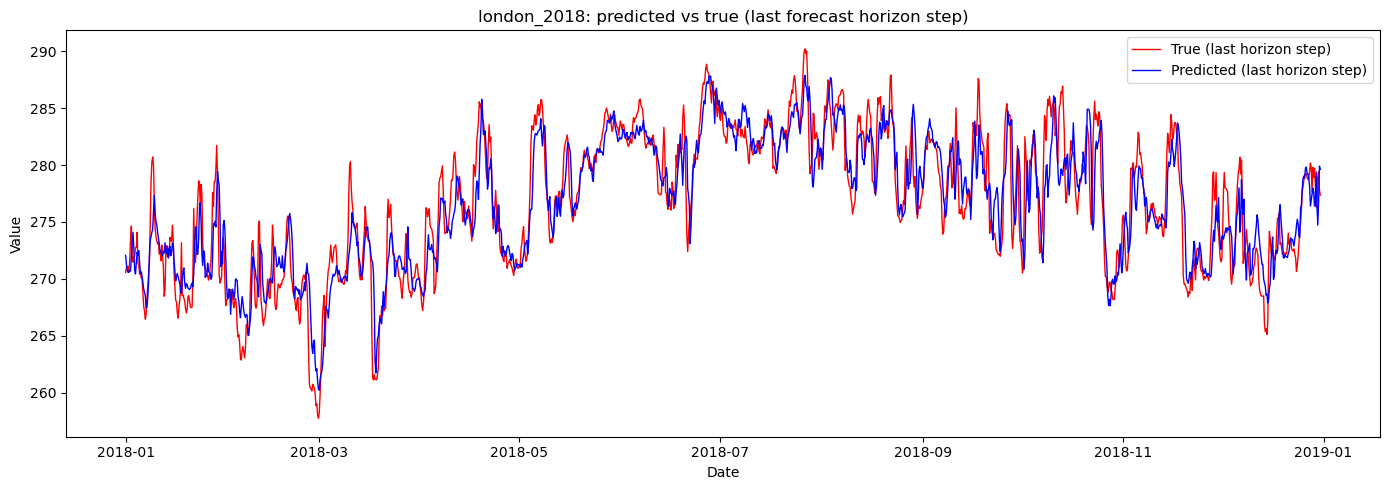

In [18]:
# 4) Inference & visualization
print('Running inference on test set...')
df = inference_collect_last(model, dm, torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
csv_out = f"{out_prefix}_train_pred_last.csv"
png_out = f"{out_prefix}_train_pred_last.png"
df.to_csv(csv_out, index=False)
print(f'Saved predictions to {csv_out}')

plt.figure(figsize=(14, 5))
plt.plot(df['timestamp'], df['true_last'], label='True (last horizon step)', color='red', linewidth=1)
plt.plot(df['timestamp'], df['pred_last'], label='Predicted (last horizon step)', color='blue', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Value')
plt.title(f"{city_year}: predicted vs true (last forecast horizon step)")
plt.legend()
plt.tight_layout()
plt.savefig(png_out, dpi=150)
print(f'Saved plot to {png_out}')

In [19]:
# Now let's take a look at patchtst
patchtst_model = build_model('patchtst', dm, seq_length, pred_length, lr, weight_decay)

In [ ]:
device = 1 if torch.cuda.is_available() else None
trainer = L.Trainer(max_epochs=epochs, accelerator='auto', devices=device, enable_checkpointing=False, logger=False)
print(f'Starting training for {epochs} epochs...')
trainer.fit(patchtst_model, dm.train_dataloader(), dm.val_dataloader())

Running inference on test set...
Saved predictions to quickstart_london_train_pred_last.csv
Saved plot to quickstart_london_train_pred_last.png


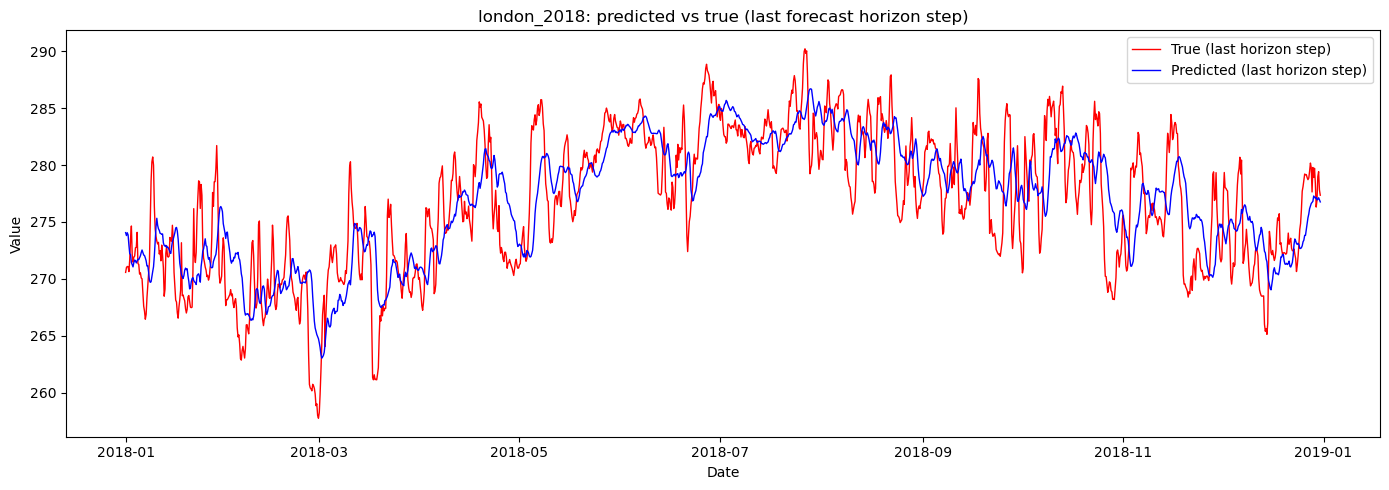

In [21]:
print('Running inference on test set...')
df = inference_collect_last(patchtst_model, dm, torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
csv_out = f"{out_prefix}_train_pred_last.csv"
png_out = f"{out_prefix}_train_pred_last.png"
df.to_csv(csv_out, index=False)
print(f'Saved predictions to {csv_out}')

plt.figure(figsize=(14, 5))
plt.plot(df['timestamp'], df['true_last'], label='True (last horizon step)', color='red', linewidth=1)
plt.plot(df['timestamp'], df['pred_last'], label='Predicted (last horizon step)', color='blue', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Value')
plt.title(f"{city_year}: predicted vs true (last forecast horizon step)")
plt.legend()
plt.tight_layout()
plt.savefig(png_out, dpi=150)
print(f'Saved plot to {png_out}')